# Fase 1 — Análise Descritiva: Candidatos 2026 (TSE)
## Deputado Federal — Região Centro-Oeste (DF, GO, MS, MT)

Este notebook carrega o dataset já limpo pela **Fase 0** (`dados/candidatos_...csv`) e faz uma análise descritiva: distribuições, outliers, variáveis categóricas, correlações e cruzamentos entre variáveis — sem alterar o dataset em si (isso fica pra Fase 2, clusterização).

## Configuração

Use exatamente os mesmos valores de `CARGO`, `UF` e `ANO_ELEICAO` da Fase 0, para carregar o mesmo arquivo.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

CARGO = "DEPUTADO FEDERAL"
UF = ["DF", "GO", "MS", "MT"]
ANO_ELEICAO = 2026

if UF is None:
    nome_uf = 'BRASIL'
elif isinstance(UF, str):
    nome_uf = UF
else:
    nome_uf = "_".join(UF)

nome_cargo = CARGO.replace(' ', '_')
arquivo_entrada = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo_entrada)
print(f"Dataset carregado: {arquivo_entrada}")
print(f"{df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Dataset carregado: dados/candidatos_DEPUTADO_FEDERAL_DF_GO_MS_MT_2026.csv
683 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,2026-08-25,19:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532001,3022,ALESSANDRA ALMEIDA CHIANELLI DUTRA,ALE CHIANELLI,#NULO,58442472134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,DF,1972-11-28,11236642070,4,FEMININO,8,SUPERIOR COMPLETO,9,DIVORCIADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,130000.0,0.0,0.0,0.0,0.0,130000.0,11.775297,53
1,2026-08-25,19:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532002,3012,PAULO CESAR ECHEBARRIA DE CARVALHO,PAULO ECHEBARRIA,#NULO,37959077134,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1965-10-20,7033782089,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,0.0,380000.0,0.0,0.0,0.0,15000000.0,15380000.0,16.548579,60
2,2026-08-25,19:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532003,3004,FLAVIO HENRIQUE TORMINN FLEURY,FLAVIO FLEURY,#NULO,88847560144,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1981-09-01,46935651074,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,114,FISIOTERAPEUTA E TERAPEUTA OCUPACIONAL,-1,#NULO,0.0,53000.0,0.0,0.0,0.0,0.0,53000.0,10.878066,45
3,2026-08-25,19:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532004,3030,CARINE TEIXEIRA MARQUES,CARINE TEIXEIRA,#NULO,1642767182,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,GO,1986-08-25,52572671066,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),2,PRETA,257,EMPRESÁRIO,-1,#NULO,0.0,0.0,0.0,0.0,120000.0,0.0,120000.0,11.695255,40
4,2026-08-25,19:30:36,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,DF,DF,DISTRITO FEDERAL,6,DEPUTADO FEDERAL,70002532005,3010,EMILIO KERBER FILHO,EMILIO KERBER,#NULO,92759130053,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,70001800084,PARTIDO ISOLADO,NOVO,PR,1976-08-31,263044410167,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,185,ESCRITOR E CRÍTICO,-1,#NULO,1380000.0,0.0,0.0,0.0,0.0,0.0,1380000.0,14.137595,50


## 1) Visão geral do dataset

In [2]:
colunas_interesse = ['NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'DS_GENERO', 'DS_COR_RACA',
                      'DS_GRAU_INSTRUCAO', 'DS_OCUPACAO', 'SG_UF_NASCIMENTO', 'IDADE',
                      'Total_Bens', 'Total_Bens_Log']

print("Valores ausentes nas colunas de interesse:")
print(df[colunas_interesse].isna().sum())
print()
print("Estatísticas descritivas (IDADE e Total_Bens):")
df[['IDADE', 'Total_Bens']].describe()

Valores ausentes nas colunas de interesse:
NM_CANDIDATO         0
SG_UF                0
SG_PARTIDO           0
DS_GENERO            0
DS_COR_RACA          0
DS_GRAU_INSTRUCAO    0
DS_OCUPACAO          0
SG_UF_NASCIMENTO     0
IDADE                0
Total_Bens           0
Total_Bens_Log       0
dtype: int64

Estatísticas descritivas (IDADE e Total_Bens):


,IDADE,Total_Bens
count,683.000000,6.830000e+02
mean,48.601757,2.050551e+06
std,12.465417,8.438467e+06
min,21.000000,0.000000e+00
25%,40.000000,0.000000e+00
50%,48.000000,2.172881e+05
75%,57.000000,1.000000e+06
max,86.000000,1.037336e+08


**Leitura:** não há valores ausentes nas colunas usadas nesta análise — a Fase 0 já tratou isso (idades inválidas foram removidas, e patrimônio sem declaração foi preenchido com zero). São 683 candidatos, com idade entre 21 e 86 anos e patrimônio declarado entre R\$ 0 e mais de R\$ 100 milhões — essa amplitude enorme no patrimônio já antecipa uma distribuição bem assimétrica, que vamos olhar a seguir.

## 2) Distribuição das variáveis numéricas

### 2.1) Idade

Assimetria (skewness) da idade: 0.087


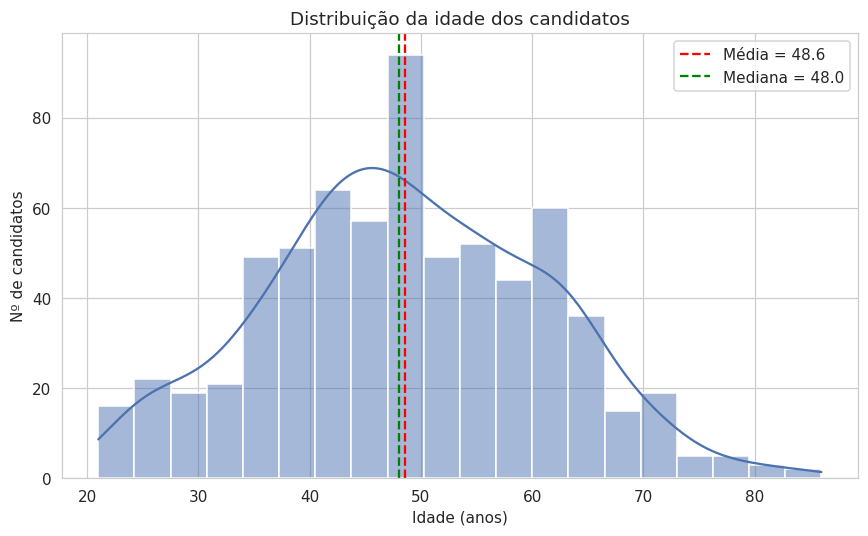

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['IDADE'], bins=20, kde=True, ax=ax, color='#4C72B0')
ax.axvline(df['IDADE'].mean(), color='red', linestyle='--', label=f"Média = {df['IDADE'].mean():.1f}")
ax.axvline(df['IDADE'].median(), color='green', linestyle='--', label=f"Mediana = {df['IDADE'].median():.1f}")
ax.set_title('Distribuição da idade dos candidatos')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Nº de candidatos')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Assimetria (skewness) da idade: {df['IDADE'].skew():.3f}")

**Leitura:** a distribuição da idade é praticamente **simétrica** (assimetria ≈ 0,09, bem perto de zero) — média (48,6 anos) e mediana (48 anos) quase coincidem, e o histograma tem o formato de sino característico de uma distribuição sem cauda longa de um lado só. Faz sentido: a idade de candidatos não tem um "teto" artificial que force distorção, diferente do patrimônio (a seguir).

### 2.2) Patrimônio declarado

Assimetria (skewness) do patrimônio (escala original): 8.34
Assimetria (skewness) do patrimônio (log): -0.76
Candidatos com patrimônio declarado igual a zero: 190 (27.8%)


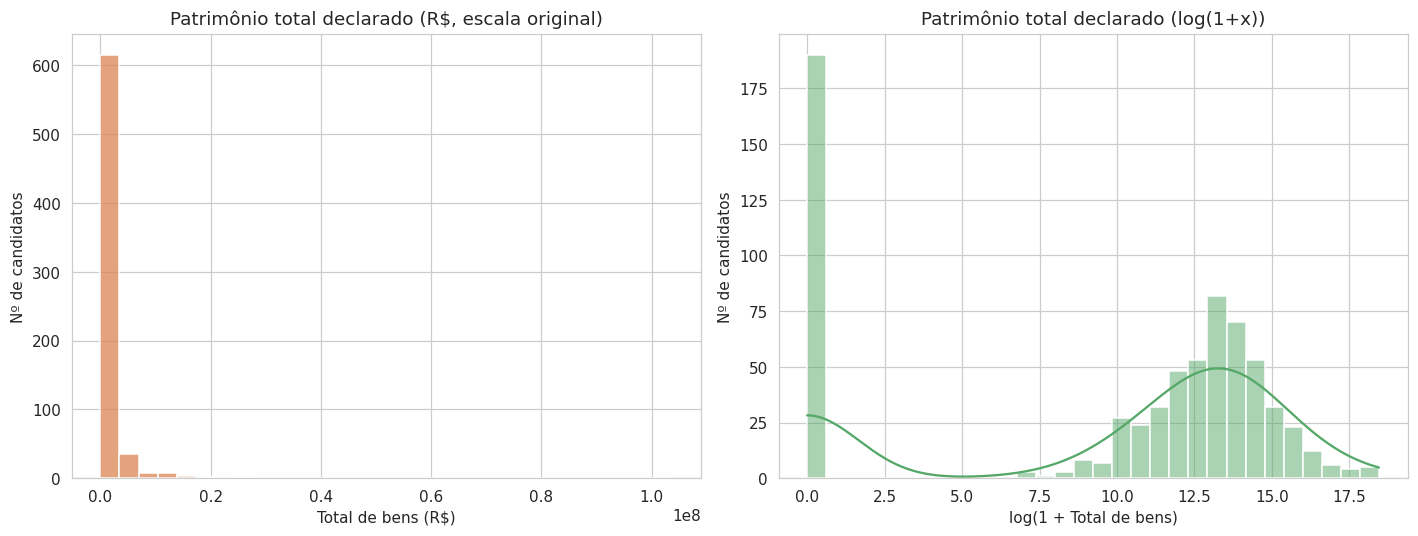

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['Total_Bens'], bins=30, ax=axes[0], color='#DD8452')
axes[0].set_title('Patrimônio total declarado (R$, escala original)')
axes[0].set_xlabel('Total de bens (R$)')
axes[0].set_ylabel('Nº de candidatos')

sns.histplot(df['Total_Bens_Log'], bins=30, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('Patrimônio total declarado (log(1+x))')
axes[1].set_xlabel('log(1 + Total de bens)')
axes[1].set_ylabel('Nº de candidatos')

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness) do patrimônio (escala original): {df['Total_Bens'].skew():.2f}")
print(f"Assimetria (skewness) do patrimônio (log): {df['Total_Bens_Log'].skew():.2f}")
print(f"Candidatos com patrimônio declarado igual a zero: {(df['Total_Bens']==0).sum()} ({(df['Total_Bens']==0).mean()*100:.1f}%)")

**Leitura:** na escala original, o patrimônio é **fortemente assimétrico à direita** (skewness ≈ 8,3) — quase todo mundo se amontoa perto de zero, com uma cauda longa de poucos candidatos milionários esticando o gráfico (o eixo x vai até mais de R\$ 100 milhões, mas a maioria declara valores bem menores). É exatamente o padrão de "poucos com muito, muitos com pouco" comum em dados de patrimônio/renda.

Depois de aplicar o log, a assimetria muda de sinal (fica ≈ −0,76) — o que parece estranho à primeira vista, mas tem explicação: **27,8% dos candidatos declararam patrimônio zero**. Como log(1+0) = 0, esse grupo inteiro vira um pico separado colado no zero, enquanto o restante dos candidatos forma um segundo agrupamento mais à direita — ou seja, a distribuição do log não é bem comportada, e sim **bimodal** (dois "montes": os que não têm bens e os que têm). Isso é um achado relevante pra Fase 2 (clusterização): esse grupo de patrimônio zero provavelmente vai formar seu próprio cluster.

## 3) Identificação de outliers

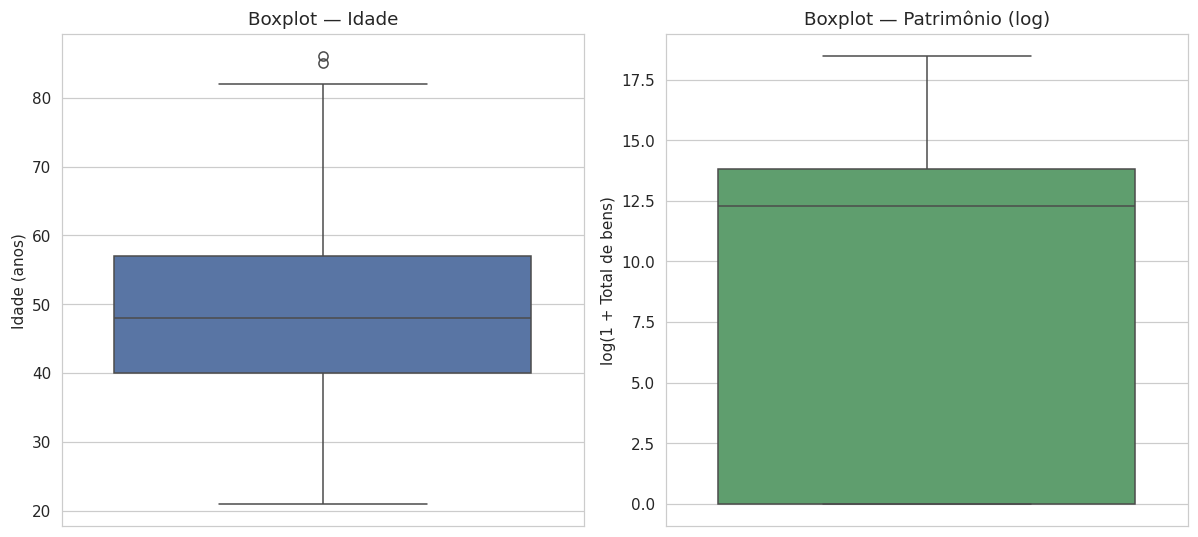

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.boxplot(y=df['IDADE'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Boxplot — Idade')
axes[0].set_ylabel('Idade (anos)')

sns.boxplot(y=df['Total_Bens_Log'], ax=axes[1], color='#55A868')
axes[1].set_title('Boxplot — Patrimônio (log)')
axes[1].set_ylabel('log(1 + Total de bens)')

plt.tight_layout()
plt.show()

In [6]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return limite_inferior, limite_superior, serie[(serie < limite_inferior) | (serie > limite_superior)]

low, high, out_idade = outliers_iqr(df['IDADE'])
print(f"IDADE — limites IQR: [{low:.1f}, {high:.1f}] anos  ->  {len(out_idade)} outlier(s)")
print(df.loc[out_idade.index, ['NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'IDADE']])
print()

low, high, out_bens = outliers_iqr(df['Total_Bens'])
print(f"Total_Bens — limites IQR: [{low:,.0f}, {high:,.0f}]  ->  {len(out_bens)} outliers ({len(out_bens)/len(df)*100:.1f}% dos candidatos)")
print()
print("10 maiores patrimônios entre os outliers:")
out_bens_df = df.loc[out_bens.index, ['NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'Total_Bens']]
out_bens_df.sort_values('Total_Bens', ascending=False).head(10)

IDADE — limites IQR: [14.5, 82.5] anos  ->  2 outlier(s)
                 NM_CANDIDATO SG_UF SG_PARTIDO  IDADE
326  ADAIR HENRIQUES DA SILVA    GO       PSDB     85
661           FRANCISCO DE SA    MS     AVANTE     86

Total_Bens — limites IQR: [-1,500,000, 2,500,000]  ->  84 outliers (12.3% dos candidatos)

10 maiores patrimônios entre os outliers:


,NM_CANDIDATO,SG_UF,SG_PARTIDO,Total_Bens
340,FLÁVIA MODESTO TELES,GO,PSDB,1.037336e+08
111,ANA PAULA FEROLA ARAUJO,DF,AVANTE,9.500000e+07
335,FELIPE SOARES CECILIO,GO,PSDB,8.682945e+07
19,ADRIANO MARANHÃO DO AMARAL,DF,PSD,6.675775e+07
245,MAGDA MOFATTO HON,GO,PL,6.294432e+07
246,RENATO RIBEIRO DOS SANTOS,GO,PL,5.395022e+07
488,CRISTIANO CARLOS DA SILVA,MT,PDT,5.034500e+07
276,JOSE NELTO LAGARES DAS MERCEZ,GO,UNIÃO,4.636391e+07
62,JOSE HUMBERTO PIRES DE ARAUJO,DF,MDB,3.461020e+07
619,APARECIDO CARLOS BERNARDO,MS,UNIÃO,2.872479e+07


**Leitura:**
- **Idade:** a regra do IQR aponta só **2 outliers** — candidatos com 85 e 86 anos (GO e MS). Não são erros de cadastro (já filtramos isso na Fase 0), só candidatos genuinamente mais velhos que a maioria; a distribuição de idade é bem comportada, então o IQR pega só os casos realmente extremos.
- **Patrimônio:** a mesma regra aponta **84 outliers (12,3% dos candidatos)** — um número bem mais alto, e isso é esperado, não um problema nos dados. Quando a distribuição é muito assimétrica (como vimos acima), a regra do IQR classifica como "outlier" qualquer coisa acima de ~R\$ 2,5 milhões, o que aqui significa mais "candidato rico" do que "erro de digitação". O maior patrimônio declarado passa de R\$ 100 milhões. Por isso o notebook da Fase 0 optou por **não remover** esses outliers agora — o tratamento (remover, usar log, winsorizar, etc.) depende da técnica que a Fase 2 for usar.

## 4) Variáveis categóricas

### 4.1) Gênero

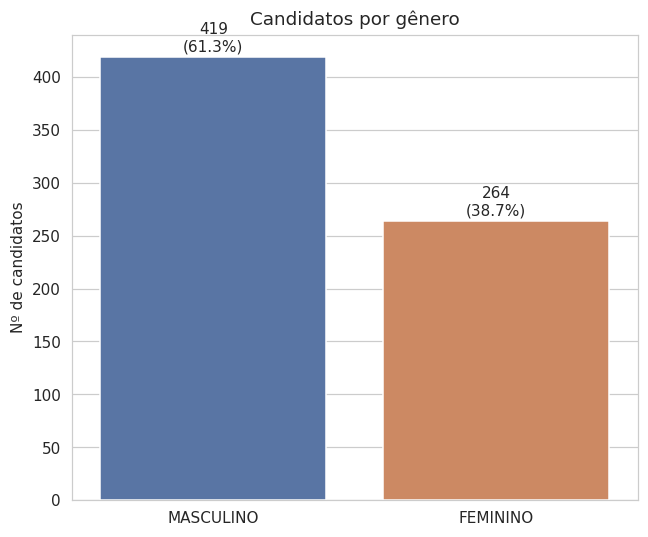

In [7]:
genero_counts = df['DS_GENERO'].value_counts()
genero_prop = df['DS_GENERO'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=genero_counts.index, y=genero_counts.values, ax=ax, hue=genero_counts.index,
            palette=['#4C72B0', '#DD8452'], legend=False)
for i, (v, p) in enumerate(zip(genero_counts.values, genero_prop.values)):
    ax.text(i, v + 5, f"{v}\n({p:.1f}%)", ha='center')
ax.set_title('Candidatos por gênero')
ax.set_ylabel('Nº de candidatos')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 4.2) Cor/raça

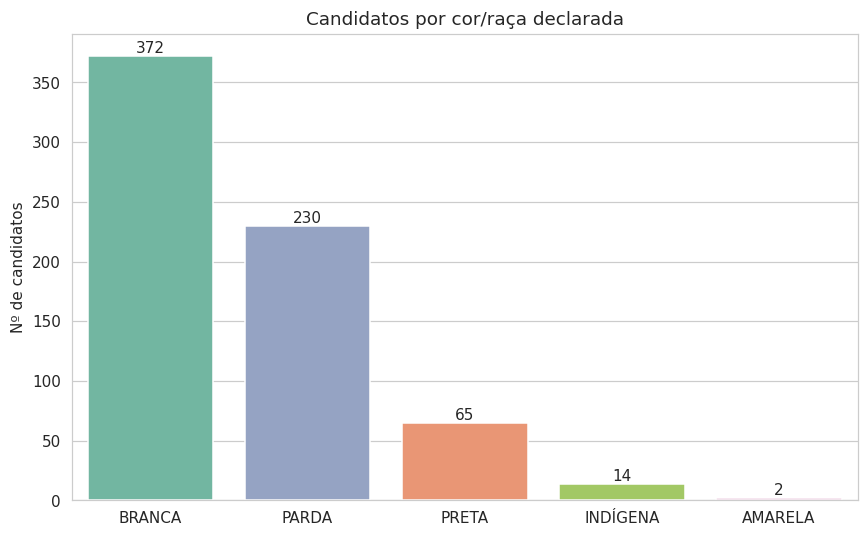

DS_COR_RACA
BRANCA      54.5
PARDA       33.7
PRETA        9.5
INDÍGENA     2.0
AMARELA      0.3
Name: proportion, dtype: float64

In [8]:
ordem_raca = df['DS_COR_RACA'].value_counts().index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='DS_COR_RACA', order=ordem_raca, hue='DS_COR_RACA',
              palette='Set2', legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
ax.set_title('Candidatos por cor/raça declarada')
ax.set_xlabel('')
ax.set_ylabel('Nº de candidatos')
plt.tight_layout()
plt.show()

(df['DS_COR_RACA'].value_counts(normalize=True) * 100).round(1)

### 4.3) Grau de instrução

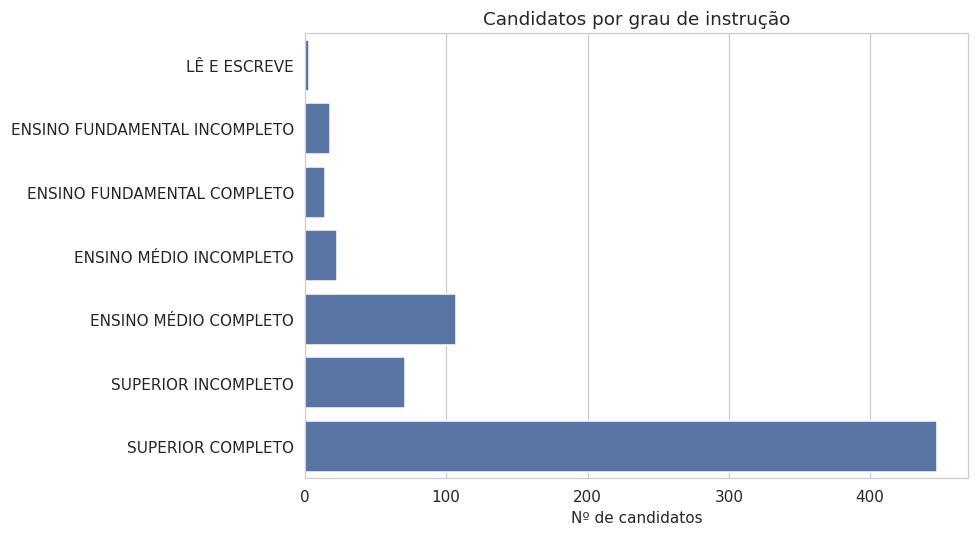

In [9]:
ordem_instrucao = [
    'LÊ E ESCREVE', 'ENSINO FUNDAMENTAL INCOMPLETO', 'ENSINO FUNDAMENTAL COMPLETO',
    'ENSINO MÉDIO INCOMPLETO', 'ENSINO MÉDIO COMPLETO', 'SUPERIOR INCOMPLETO', 'SUPERIOR COMPLETO'
]
contagem_instrucao = df['DS_GRAU_INSTRUCAO'].value_counts().reindex(ordem_instrucao).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=contagem_instrucao.values, y=contagem_instrucao.index, ax=ax, color='#4C72B0', orient='h')
ax.set_title('Candidatos por grau de instrução')
ax.set_xlabel('Nº de candidatos')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.4) Partido

Total de legendas com candidatos: 27
Mais candidatos: REPUBLICANOS (46)
Menos candidatos: CIDADANIA (2)


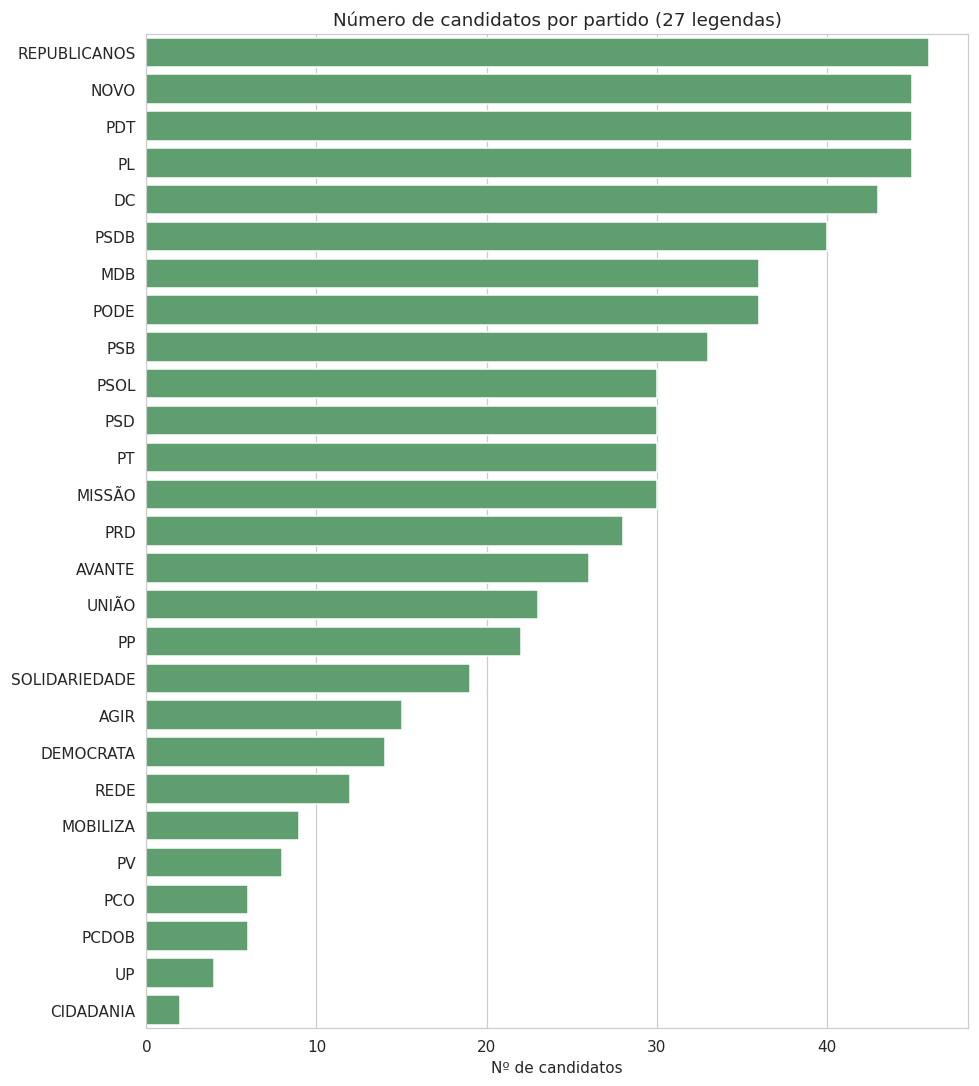

In [10]:
partido_counts = df['SG_PARTIDO'].value_counts()

fig, ax = plt.subplots(figsize=(9, 10))
sns.barplot(x=partido_counts.values, y=partido_counts.index, ax=ax, color='#55A868', orient='h')
ax.set_title(f'Número de candidatos por partido ({len(partido_counts)} legendas)')
ax.set_xlabel('Nº de candidatos')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"Total de legendas com candidatos: {len(partido_counts)}")
print(f"Mais candidatos: {partido_counts.index[0]} ({partido_counts.iloc[0]})")
print(f"Menos candidatos: {partido_counts.index[-1]} ({partido_counts.iloc[-1]})")

### 4.5) UF de nascimento

Nascidos na região Centro-Oeste (DF/GO/MS/MT): 449 (65.7%)
Nascidos fora da região: 234 (34.3%)


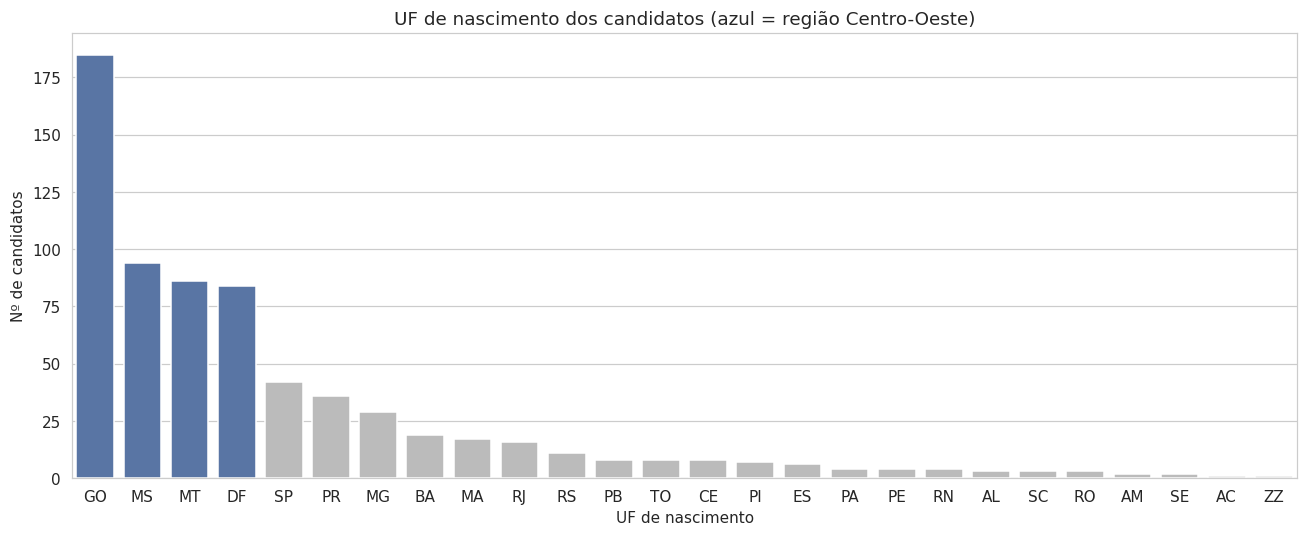

In [11]:
uf_nasc_counts = df['SG_UF_NASCIMENTO'].value_counts()
regiao = ['DF', 'GO', 'MS', 'MT']
cores = ['#4C72B0' if uf in regiao else '#BBBBBB' for uf in uf_nasc_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=uf_nasc_counts.index, y=uf_nasc_counts.values, hue=uf_nasc_counts.index,
            palette=cores, legend=False, ax=ax)
ax.set_title('UF de nascimento dos candidatos (azul = região Centro-Oeste)')
ax.set_xlabel('UF de nascimento')
ax.set_ylabel('Nº de candidatos')
plt.tight_layout()
plt.show()

nascidos_regiao = df['SG_UF_NASCIMENTO'].isin(regiao).sum()
print(f"Nascidos na região Centro-Oeste (DF/GO/MS/MT): {nascidos_regiao} ({nascidos_regiao/len(df)*100:.1f}%)")
print(f"Nascidos fora da região: {len(df)-nascidos_regiao} ({(len(df)-nascidos_regiao)/len(df)*100:.1f}%)")

### 4.6) Ocupação

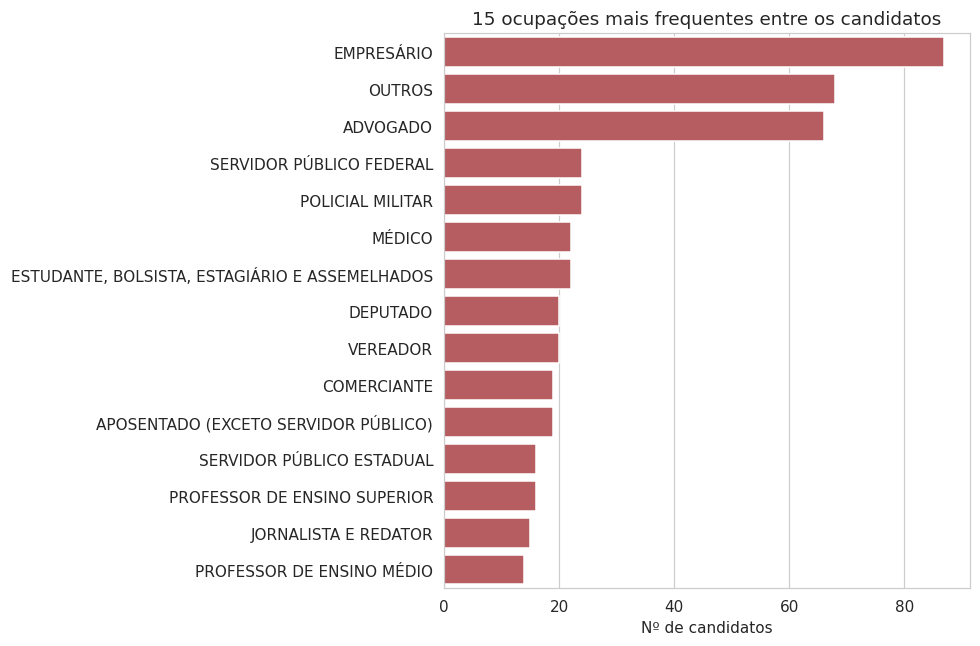

In [12]:
top_ocupacoes = df['DS_OCUPACAO'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_ocupacoes.values, y=top_ocupacoes.index, ax=ax, color='#C44E52', orient='h')
ax.set_title('15 ocupações mais frequentes entre os candidatos')
ax.set_xlabel('Nº de candidatos')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Leitura das variáveis categóricas:**
- **Gênero:** 61,3% homens (419) e 38,7% mulheres (264) — mesmo com a Lei de Cotas exigindo no mínimo 30% de candidaturas de cada gênero por partido, a proporção observada de mulheres fica próxima desse piso, e não numa divisão equilibrada.
- **Cor/raça:** candidatos que se autodeclaram brancos são maioria (54,5%), seguidos por pardos (33,7%) e pretos (9,5%); indígenas (2,0%) e amarelos (0,3%) são uma fração pequena da amostra.
- **Grau de instrução:** forte concentração em nível superior — 65,5% têm superior completo, e outros 10,4% superior incompleto; ou seja, cerca de 3 em cada 4 candidatos têm ao menos alguma formação superior, bem acima da escolaridade média da população brasileira em geral.
- **Partido:** são 27 legendas disputando as vagas na região. REPUBLICANOS lidera com 46 candidatos, seguido de perto por NOVO, PDT e PL (45 cada); no outro extremo, CIDADANIA tem só 2 candidatos na região.
- **UF de nascimento:** 65,7% dos candidatos nasceram na própria região Centro-Oeste (DF/GO/MS/MT), e 34,3% vieram de fora — um contingente relevante de "não-naturais" disputando vagas na região, algo que pode valer a pena cruzar com o desempenho eleitoral em fases futuras.
- **Ocupação:** "Empresário" é a ocupação mais declarada (87 candidatos), seguida de "Outros" (categoria genérica, 68) e "Advogado" (66) — reforçando o padrão nacional de sobrerrepresentação de perfis ligados a negócios próprios e ao direito na política brasileira.

## 5) Correlação entre variáveis numéricas

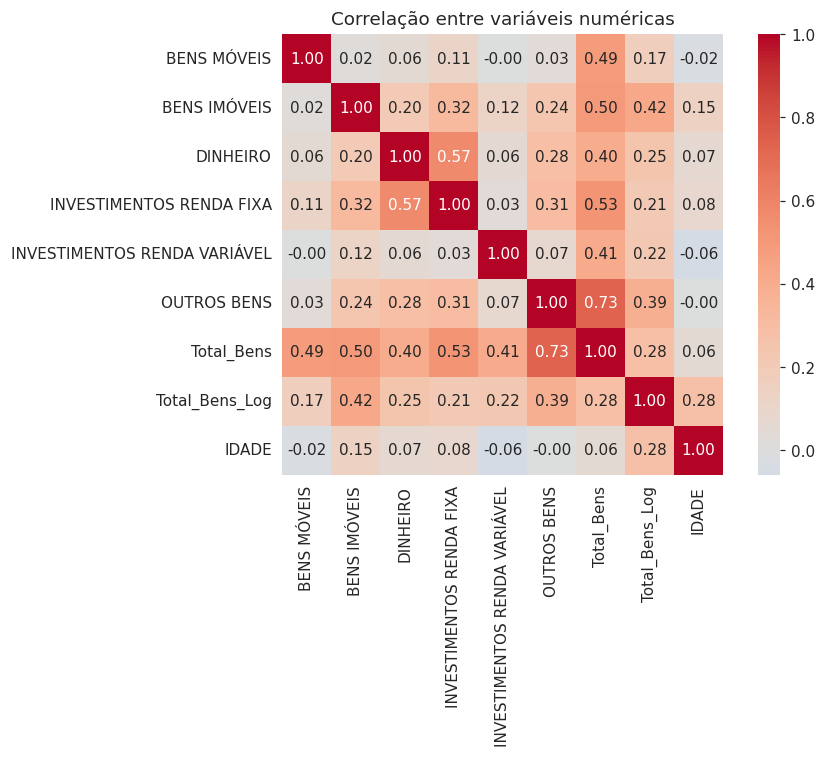

In [13]:
cols_bens = ['BENS MÓVEIS', 'BENS IMÓVEIS', 'DINHEIRO', 'INVESTIMENTOS RENDA FIXA',
             'INVESTIMENTOS RENDA VARIÁVEL', 'OUTROS BENS', 'Total_Bens', 'Total_Bens_Log', 'IDADE']
corr = df[cols_bens].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

Correlação (Pearson) IDADE x Total_Bens_Log: 0.278


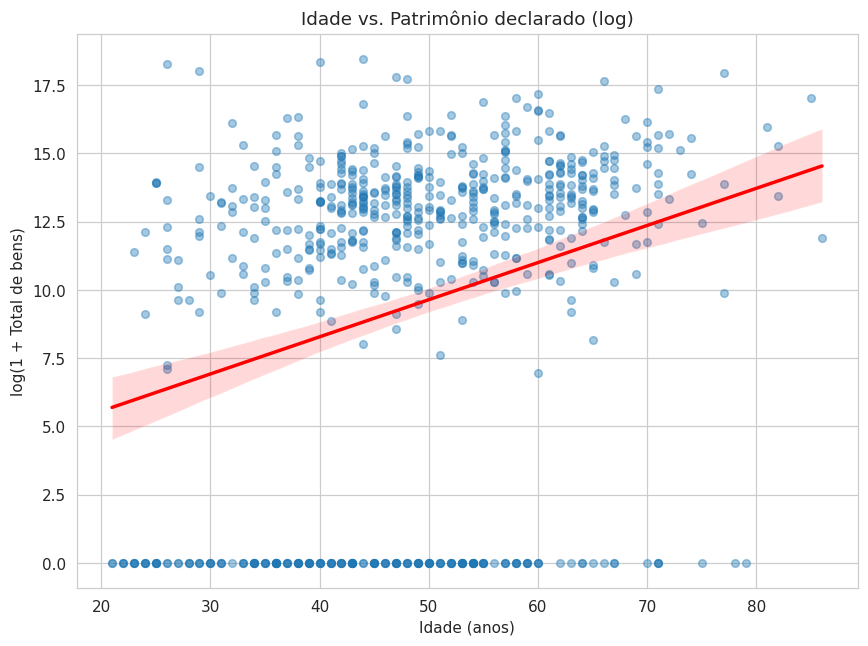

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x='IDADE', y='Total_Bens_Log', scatter_kws={'alpha': 0.4, 's': 25},
            line_kws={'color': 'red'}, ax=ax)
ax.set_title('Idade vs. Patrimônio declarado (log)')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('log(1 + Total de bens)')
plt.tight_layout()
plt.show()

print(f"Correlação (Pearson) IDADE x Total_Bens_Log: {df['IDADE'].corr(df['Total_Bens_Log']):.3f}")

**Leitura:** as correlações são fracas de modo geral. IDADE x Total_Bens_Log fica em ≈ 0,28 — uma relação linear positiva, mas fraca: candidatos mais velhos tendem a declarar um pouco mais de patrimônio (faz sentido, mais tempo pra acumular bens), mas idade está longe de "explicar" o patrimônio sozinha — o gráfico de dispersão mostra candidatos de todas as idades espalhados em praticamente todos os níveis de patrimônio. Entre as categorias de bens, não há nenhum par com correlação forte entre si — o que é esperado, já que são tipos de bens diferentes e não substitutos diretos um do outro.

## 6) Análises bivariadas

### 6.1) Patrimônio por gênero

Mediana do patrimônio (R$) por gênero:


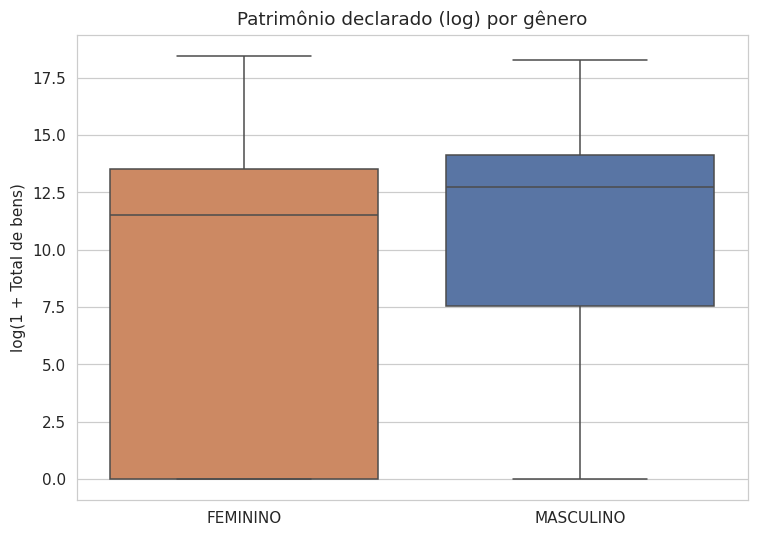

DS_GENERO
FEMININO     100000.00
MASCULINO    334029.97
Name: Total_Bens, dtype: float64

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='DS_GENERO', y='Total_Bens_Log', hue='DS_GENERO',
            palette=['#DD8452', '#4C72B0'], legend=False, ax=ax)
ax.set_title('Patrimônio declarado (log) por gênero')
ax.set_xlabel('')
ax.set_ylabel('log(1 + Total de bens)')
plt.tight_layout()
plt.show()

print("Mediana do patrimônio (R$) por gênero:")
df.groupby('DS_GENERO')['Total_Bens'].median()

### 6.2) Gênero por partido

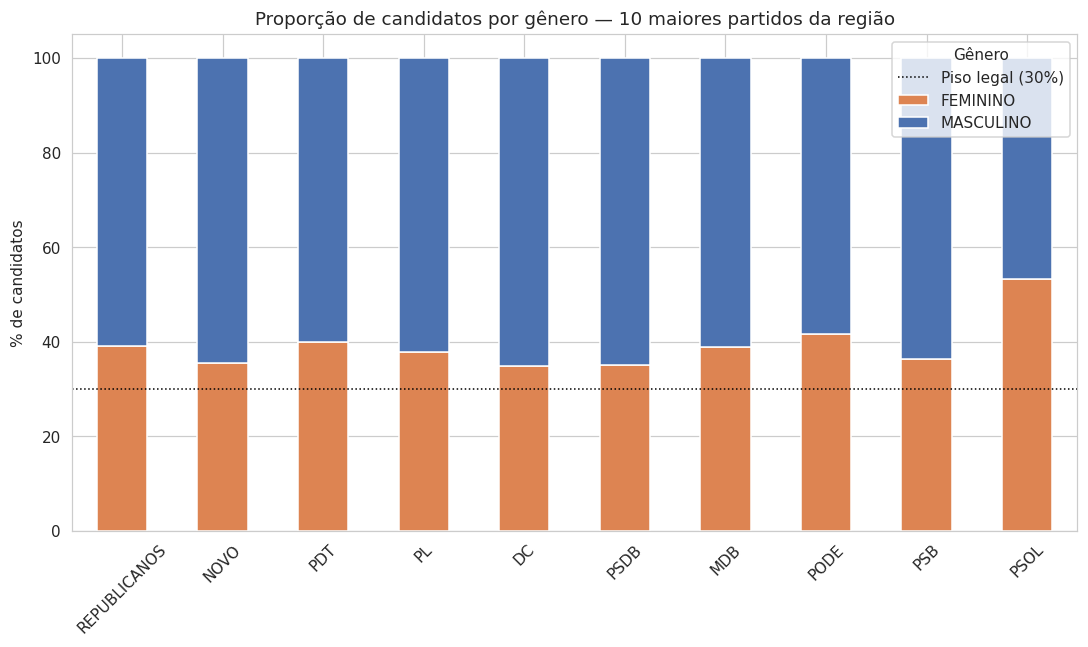

DS_GENERO,FEMININO,MASCULINO
SG_PARTIDO,,
REPUBLICANOS,18,28
NOVO,16,29
PDT,18,27
PL,17,28
DC,15,28
PSDB,14,26
MDB,14,22
PODE,15,21
PSB,12,21


In [16]:
top_partidos = df['SG_PARTIDO'].value_counts().head(10).index
sub = df[df['SG_PARTIDO'].isin(top_partidos)]

tab_genero = pd.crosstab(sub['SG_PARTIDO'], sub['DS_GENERO']).loc[top_partidos]
tab_genero_prop = tab_genero.div(tab_genero.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
tab_genero_prop.plot(kind='bar', stacked=True, ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_title('Proporção de candidatos por gênero — 10 maiores partidos da região')
ax.set_xlabel('')
ax.set_ylabel('% de candidatos')
ax.axhline(30, color='black', linestyle=':', linewidth=1, label='Piso legal (30%)')
ax.legend(title='Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tab_genero

### 6.3) Cor/raça por partido

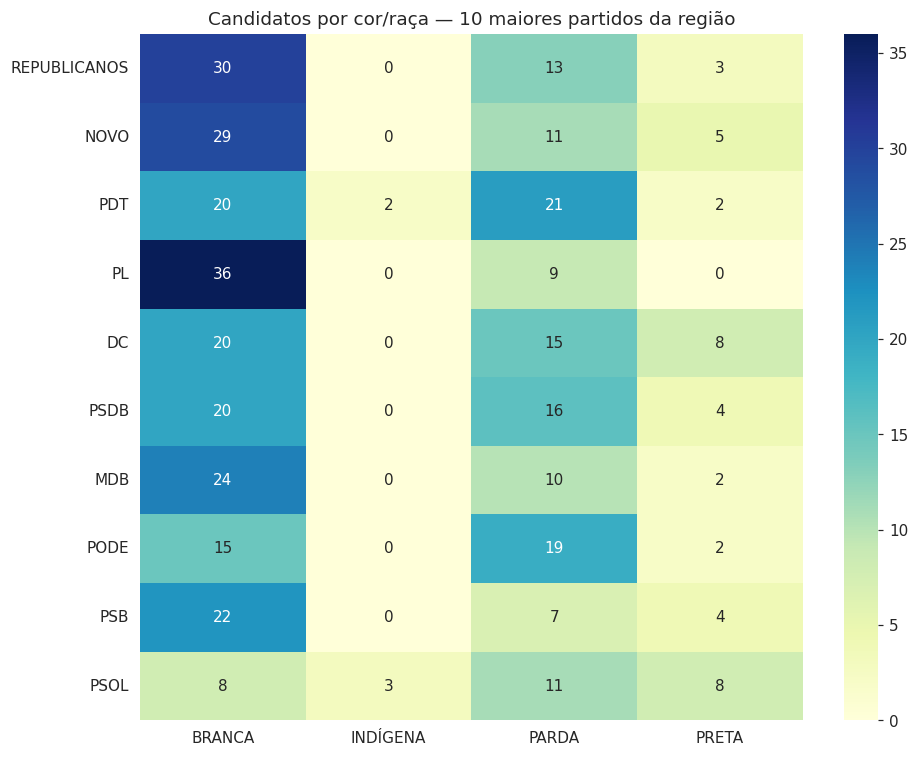

In [17]:
tab_raca = pd.crosstab(sub['SG_PARTIDO'], sub['DS_COR_RACA']).loc[top_partidos]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(tab_raca, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Candidatos por cor/raça — 10 maiores partidos da região')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Leitura das análises bivariadas:**
- **Patrimônio por gênero:** a mediana de patrimônio declarado por homens (R\$ 334.030) é mais de 3x a das mulheres (R\$ 100.000) nesta amostra. O boxplot confirma: a caixa dos homens fica deslocada pra cima da caixa das mulheres — não é só um efeito de poucos casos extremos, é uma diferença que aparece na mediana também.
- **Gênero por partido:** olhando os 10 maiores partidos da região, todos ficam **acima** do piso legal de 30% — variando de 34,9% (DC) a 53,3% (PSOL, o único dos dez com maioria de candidatas mulheres). A maioria se concentra numa faixa de 35% a 42%, ou seja, folgada em relação ao mínimo legal, mas ainda longe de uma divisão 50/50 na maior parte das legendas.
- **Cor/raça por partido:** o heatmap mostra que candidatos brancos são maioria na maior parte dos partidos analisados, mas a proporção de candidatos pardos e pretos varia visivelmente de legenda pra legenda — alguns partidos concentram uma fatia bem maior de candidaturas negras/pardas que outros, o que pode valer a pena investigar mais a fundo (por exemplo, cruzando com o valor do fundo eleitoral destinado a cada candidatura, se esse dado estiver disponível em fases futuras).

---
## 7) Síntese

Principais achados desta fase, para a região Centro-Oeste (DF, GO, MS, MT):

- **683 candidatos** a Deputado Federal, sem valores ausentes nas variáveis analisadas.
- **Idade:** distribuição simétrica, média/mediana em torno de 48 anos; só 2 outliers legítimos (85 e 86 anos).
- **Patrimônio:** fortemente concentrado — 27,8% declaram zero, e a distribuição é extremamente assimétrica à direita (uns poucos milionários puxando a cauda). 84 candidatos (12,3%) são "outliers" pela regra do IQR, refletindo desigualdade real, não erro de dados.
- **Perfil demográfico:** maioria masculina (61,3%), branca (54,5%), com superior completo (65,5%); 65,7% nasceram na própria região.
- **Correlações numéricas fracas:** idade e patrimônio têm relação linear positiva, mas fraca (r ≈ 0,28).
- **Cruzamentos:** homens declaram patrimônio consideravelmente maior que mulheres; a representatividade de gênero varia por partido, mas tende a ficar perto do piso legal de 30%.

## Próximo passo

Esses achados — em especial a concentração de patrimônio em zero, a assimetria extrema e os outliers de patrimônio — são o ponto de partida da **Fase 2 (clusterização)**, que vai decidir como tratar essas características antes de agrupar os candidatos.